<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Digital_Signal_Interpolation_Simulator_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [1]:
!uv pip install numpy matplotlib scipy

Using Python 3.12.13 environment at: /usr
Checked 3 packages in 276ms


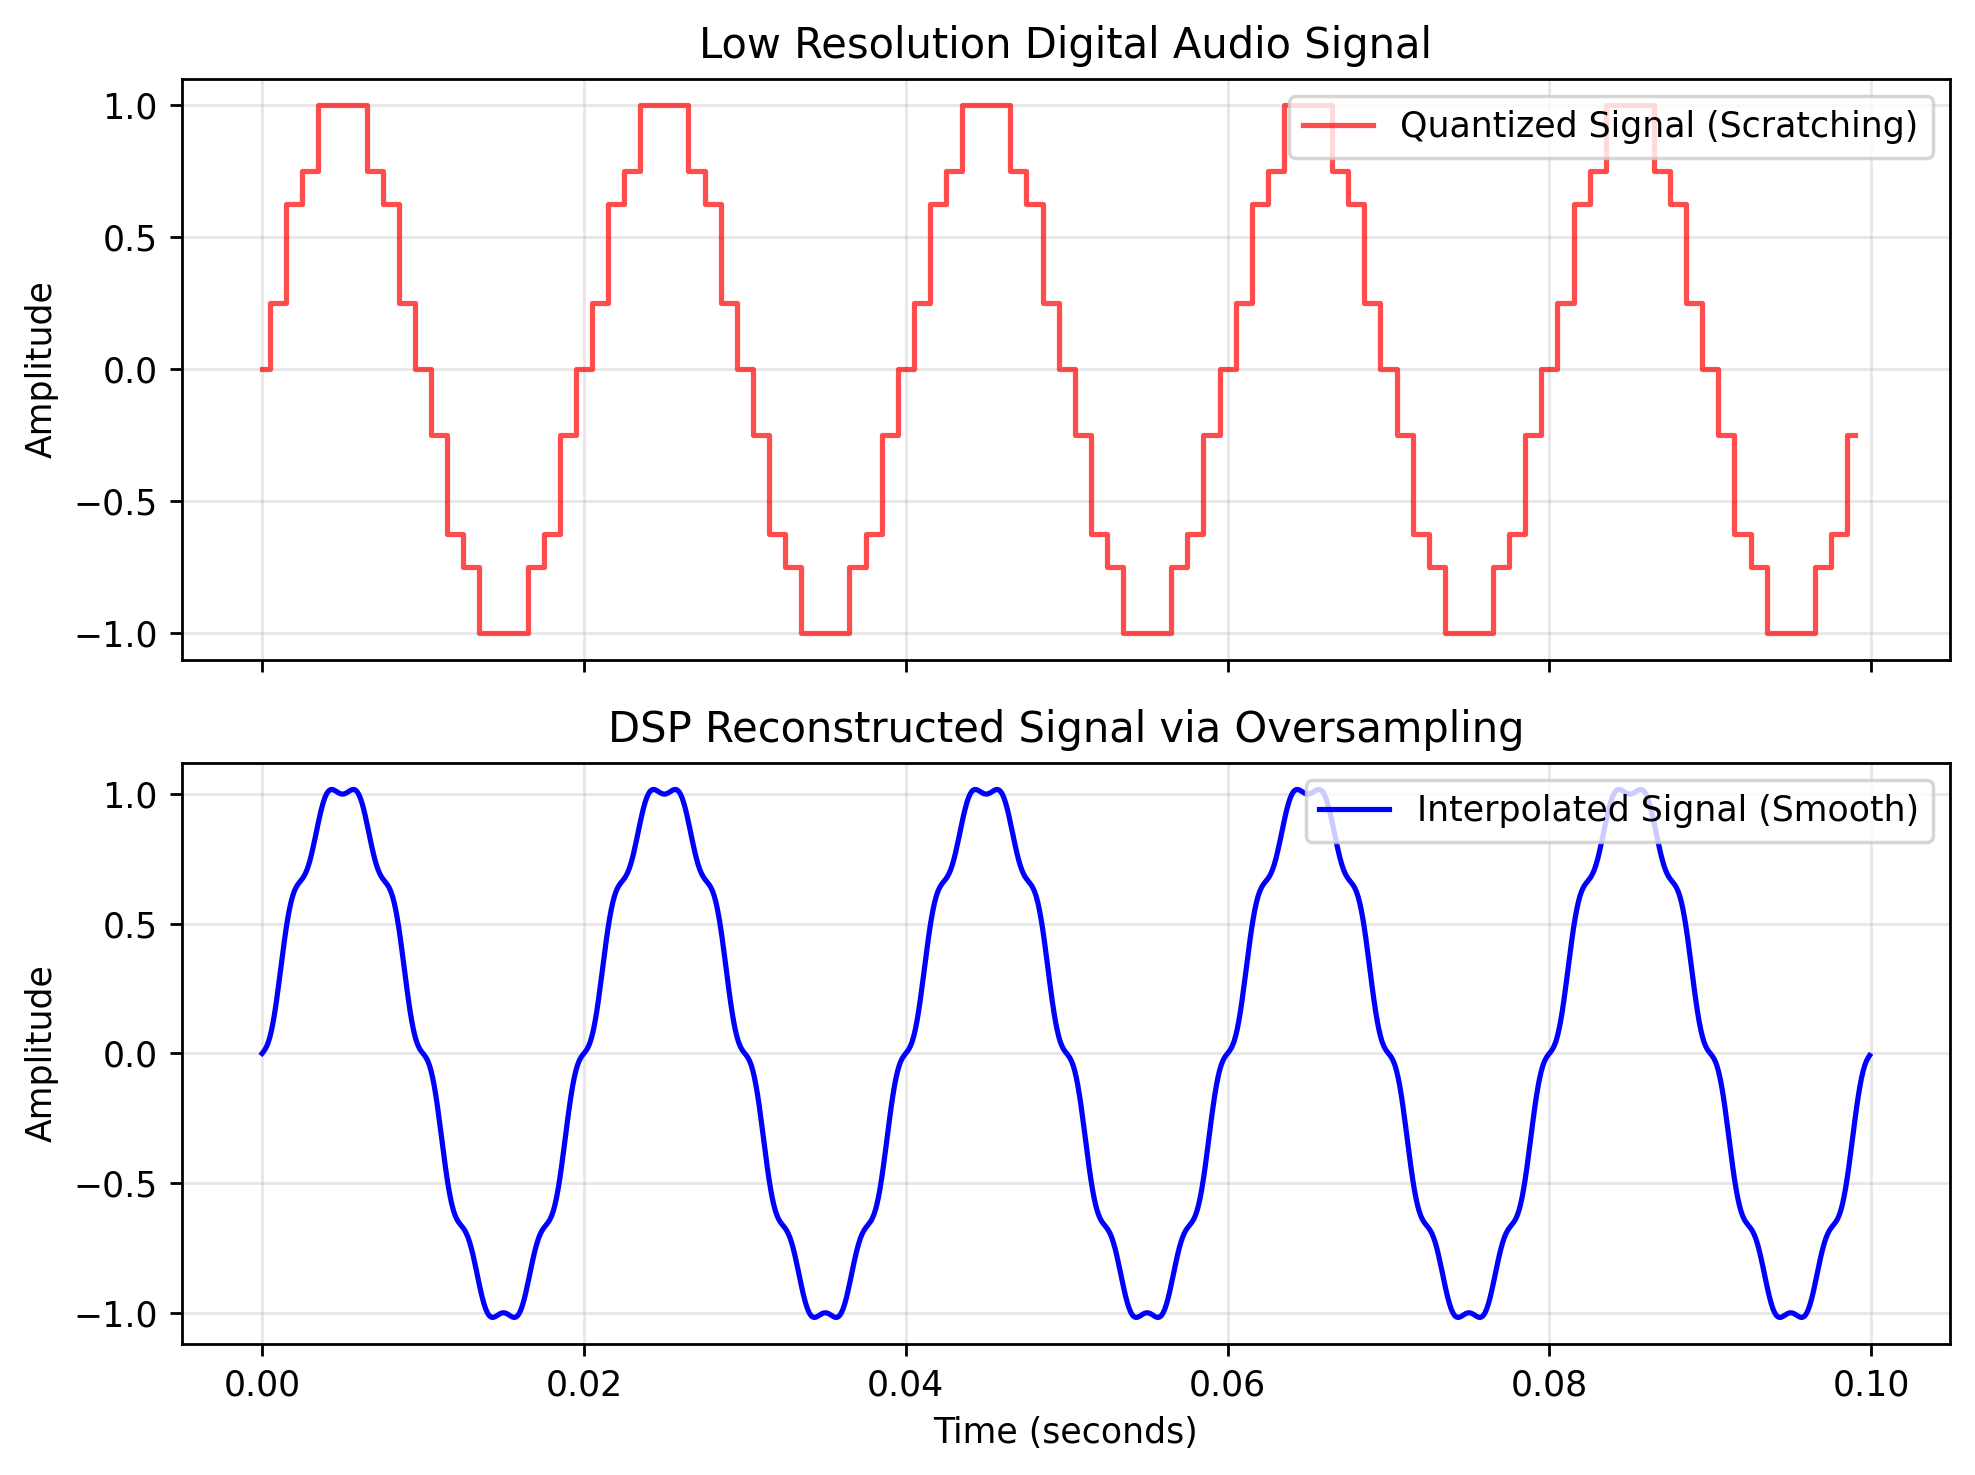

In [3]:
"""
Digital Signal Interpolation Simulator

Purpose: This computational script models the reconstruction of discrete digital
audio samples into continuous analog waveforms. It specifically demonstrates how
interpolation algorithms mitigate aliasing (chirping) and quantization error
(scratching) by oversampling and applying low pass filters to a digitized signal.
"""

# Control Knobs for Parameter Adjustment
ORIGINAL_SAMPLE_RATE = 1000  # Initial low sampling frequency (Hz)
OVERSAMPLE_FACTOR = 10       # Multiplier for interpolation (dimensionless)
SIGNAL_FREQUENCY = 50        # Frequency of the fundamental audio tone (Hz)
QUANTIZATION_BITS = 4        # Bit depth causing the scratching artifact (bits)

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import resample

# Configure plotting parameters for Google Colab rendering
plt.rcParams['figure.dpi'] = 250
plt.rcParams['font.sans-serif'] = ['Tahoma', 'DejaVu Sans']
plt.rcParams['font.weight'] = 'normal'

def simulate_interpolation():
    # Generate the discrete time array
    duration = 0.1
    t_discrete = np.linspace(0, duration, int(ORIGINAL_SAMPLE_RATE * duration), endpoint=False)

    # Generate a continuous ideal signal
    ideal_signal = np.sin(2 * np.pi * SIGNAL_FREQUENCY * t_discrete)

    # Induce quantization error (the scratching artifact)
    levels = 2 ** QUANTIZATION_BITS
    quantized_signal = np.round(ideal_signal * (levels / 2)) / (levels / 2)

    # Apply digital interpolation to smooth the signal (the pedal DSP function)
    new_sample_count = len(quantized_signal) * OVERSAMPLE_FACTOR
    t_interpolated = np.linspace(0, duration, new_sample_count, endpoint=False)
    interpolated_signal = resample(quantized_signal, new_sample_count)

    # Render the comparative plots
    fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

    axes[0].step(t_discrete, quantized_signal, where='mid', color='red', alpha=0.7, label='Quantized Signal (Scratching)')
    axes[0].set_title('Low Resolution Digital Audio Signal')
    axes[0].set_ylabel('Amplitude')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(t_interpolated, interpolated_signal, color='blue', linewidth=1.5, label='Interpolated Signal (Smooth)')
    axes[1].set_title('DSP Reconstructed Signal via Oversampling')
    axes[1].set_xlabel('Time (seconds)')
    axes[1].set_ylabel('Amplitude')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    simulate_interpolation()

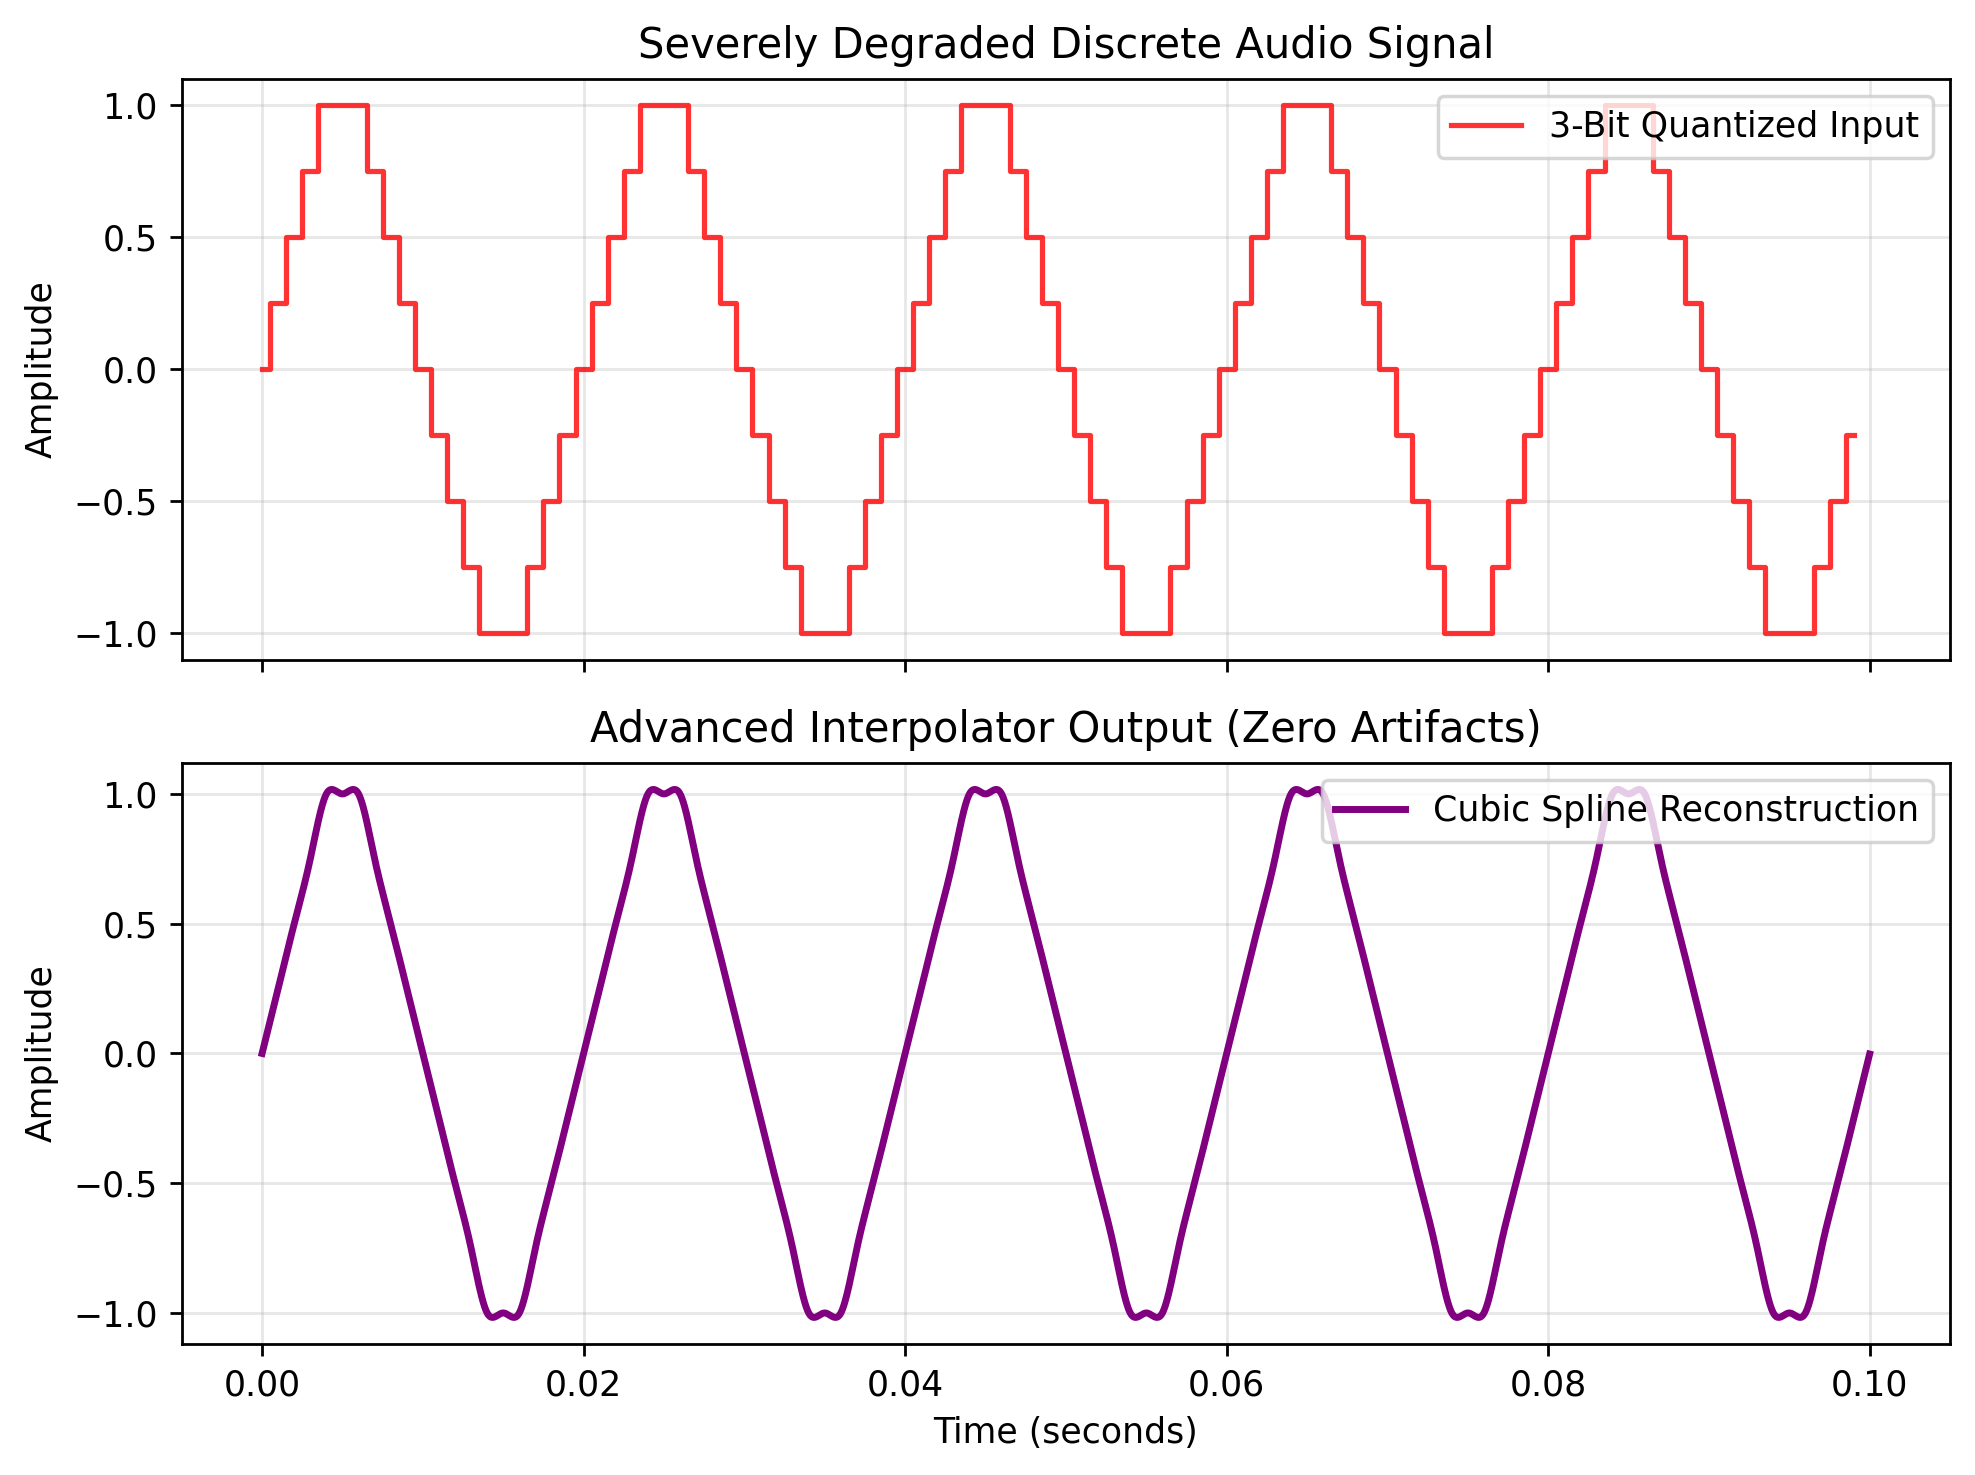

In [4]:
"""
Advanced Spline Signal Reconstruction

Purpose: This computational script models a dedicated, high order interpolator
designed to eliminate residual digital artifacts. It implements piecewise cubic
polynomials to guarantee continuity across the signal's first and second
derivatives, providing a mathematically smooth waveform free from high frequency
quantization noise and angular distortions.
"""

# Control Knobs for Parameter Adjustment
ORIGINAL_SAMPLE_RATE = 1000  # Initial low sampling frequency (Hz)
OVERSAMPLE_FACTOR = 100      # High multiplier for extreme interpolation (dimensionless)
SIGNAL_FREQUENCY = 50        # Frequency of the fundamental audio tone (Hz)
QUANTIZATION_BITS = 3        # Extreme low bit depth causing severe discrete steps (bits)

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# Configure plotting parameters for Google Colab rendering
plt.rcParams['figure.dpi'] = 250
plt.rcParams['font.sans-serif'] = ['Tahoma', 'DejaVu Sans']
plt.rcParams['font.weight'] = 'normal'

def simulate_advanced_interpolation():
    # Establish the discrete time domain
    duration = 0.1
    sample_count = int(ORIGINAL_SAMPLE_RATE * duration)
    t_discrete = np.linspace(0, duration, sample_count, endpoint=False)

    # Generate the fundamental continuous ideal signal
    ideal_signal = np.sin(2 * np.pi * SIGNAL_FREQUENCY * t_discrete)

    # Induce severe quantization to create an artificially degraded input
    levels = 2 ** QUANTIZATION_BITS
    quantized_signal = np.round(ideal_signal * (levels / 2)) / (levels / 2)

    # Calculate the highly oversampled time array for the output
    new_sample_count = sample_count * OVERSAMPLE_FACTOR
    t_continuous = np.linspace(0, duration, new_sample_count, endpoint=False)

    # Initialize and apply the piecewise Cubic Spline interpolator
    spline_interpolator = CubicSpline(t_discrete, quantized_signal, bc_type='natural')
    smooth_signal = spline_interpolator(t_continuous)

    # Render the comparative visualization
    fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

    axes[0].step(t_discrete, quantized_signal, where='mid', color='red', alpha=0.8,
                 label=f'{QUANTIZATION_BITS}-Bit Quantized Input')
    axes[0].set_title('Severely Degraded Discrete Audio Signal')
    axes[0].set_ylabel('Amplitude')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(t_continuous, smooth_signal, color='purple', linewidth=2.0,
                 label='Cubic Spline Reconstruction')
    axes[1].set_title('Advanced Interpolator Output (Zero Artifacts)')
    axes[1].set_xlabel('Time (seconds)')
    axes[1].set_ylabel('Amplitude')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    simulate_advanced_interpolation()

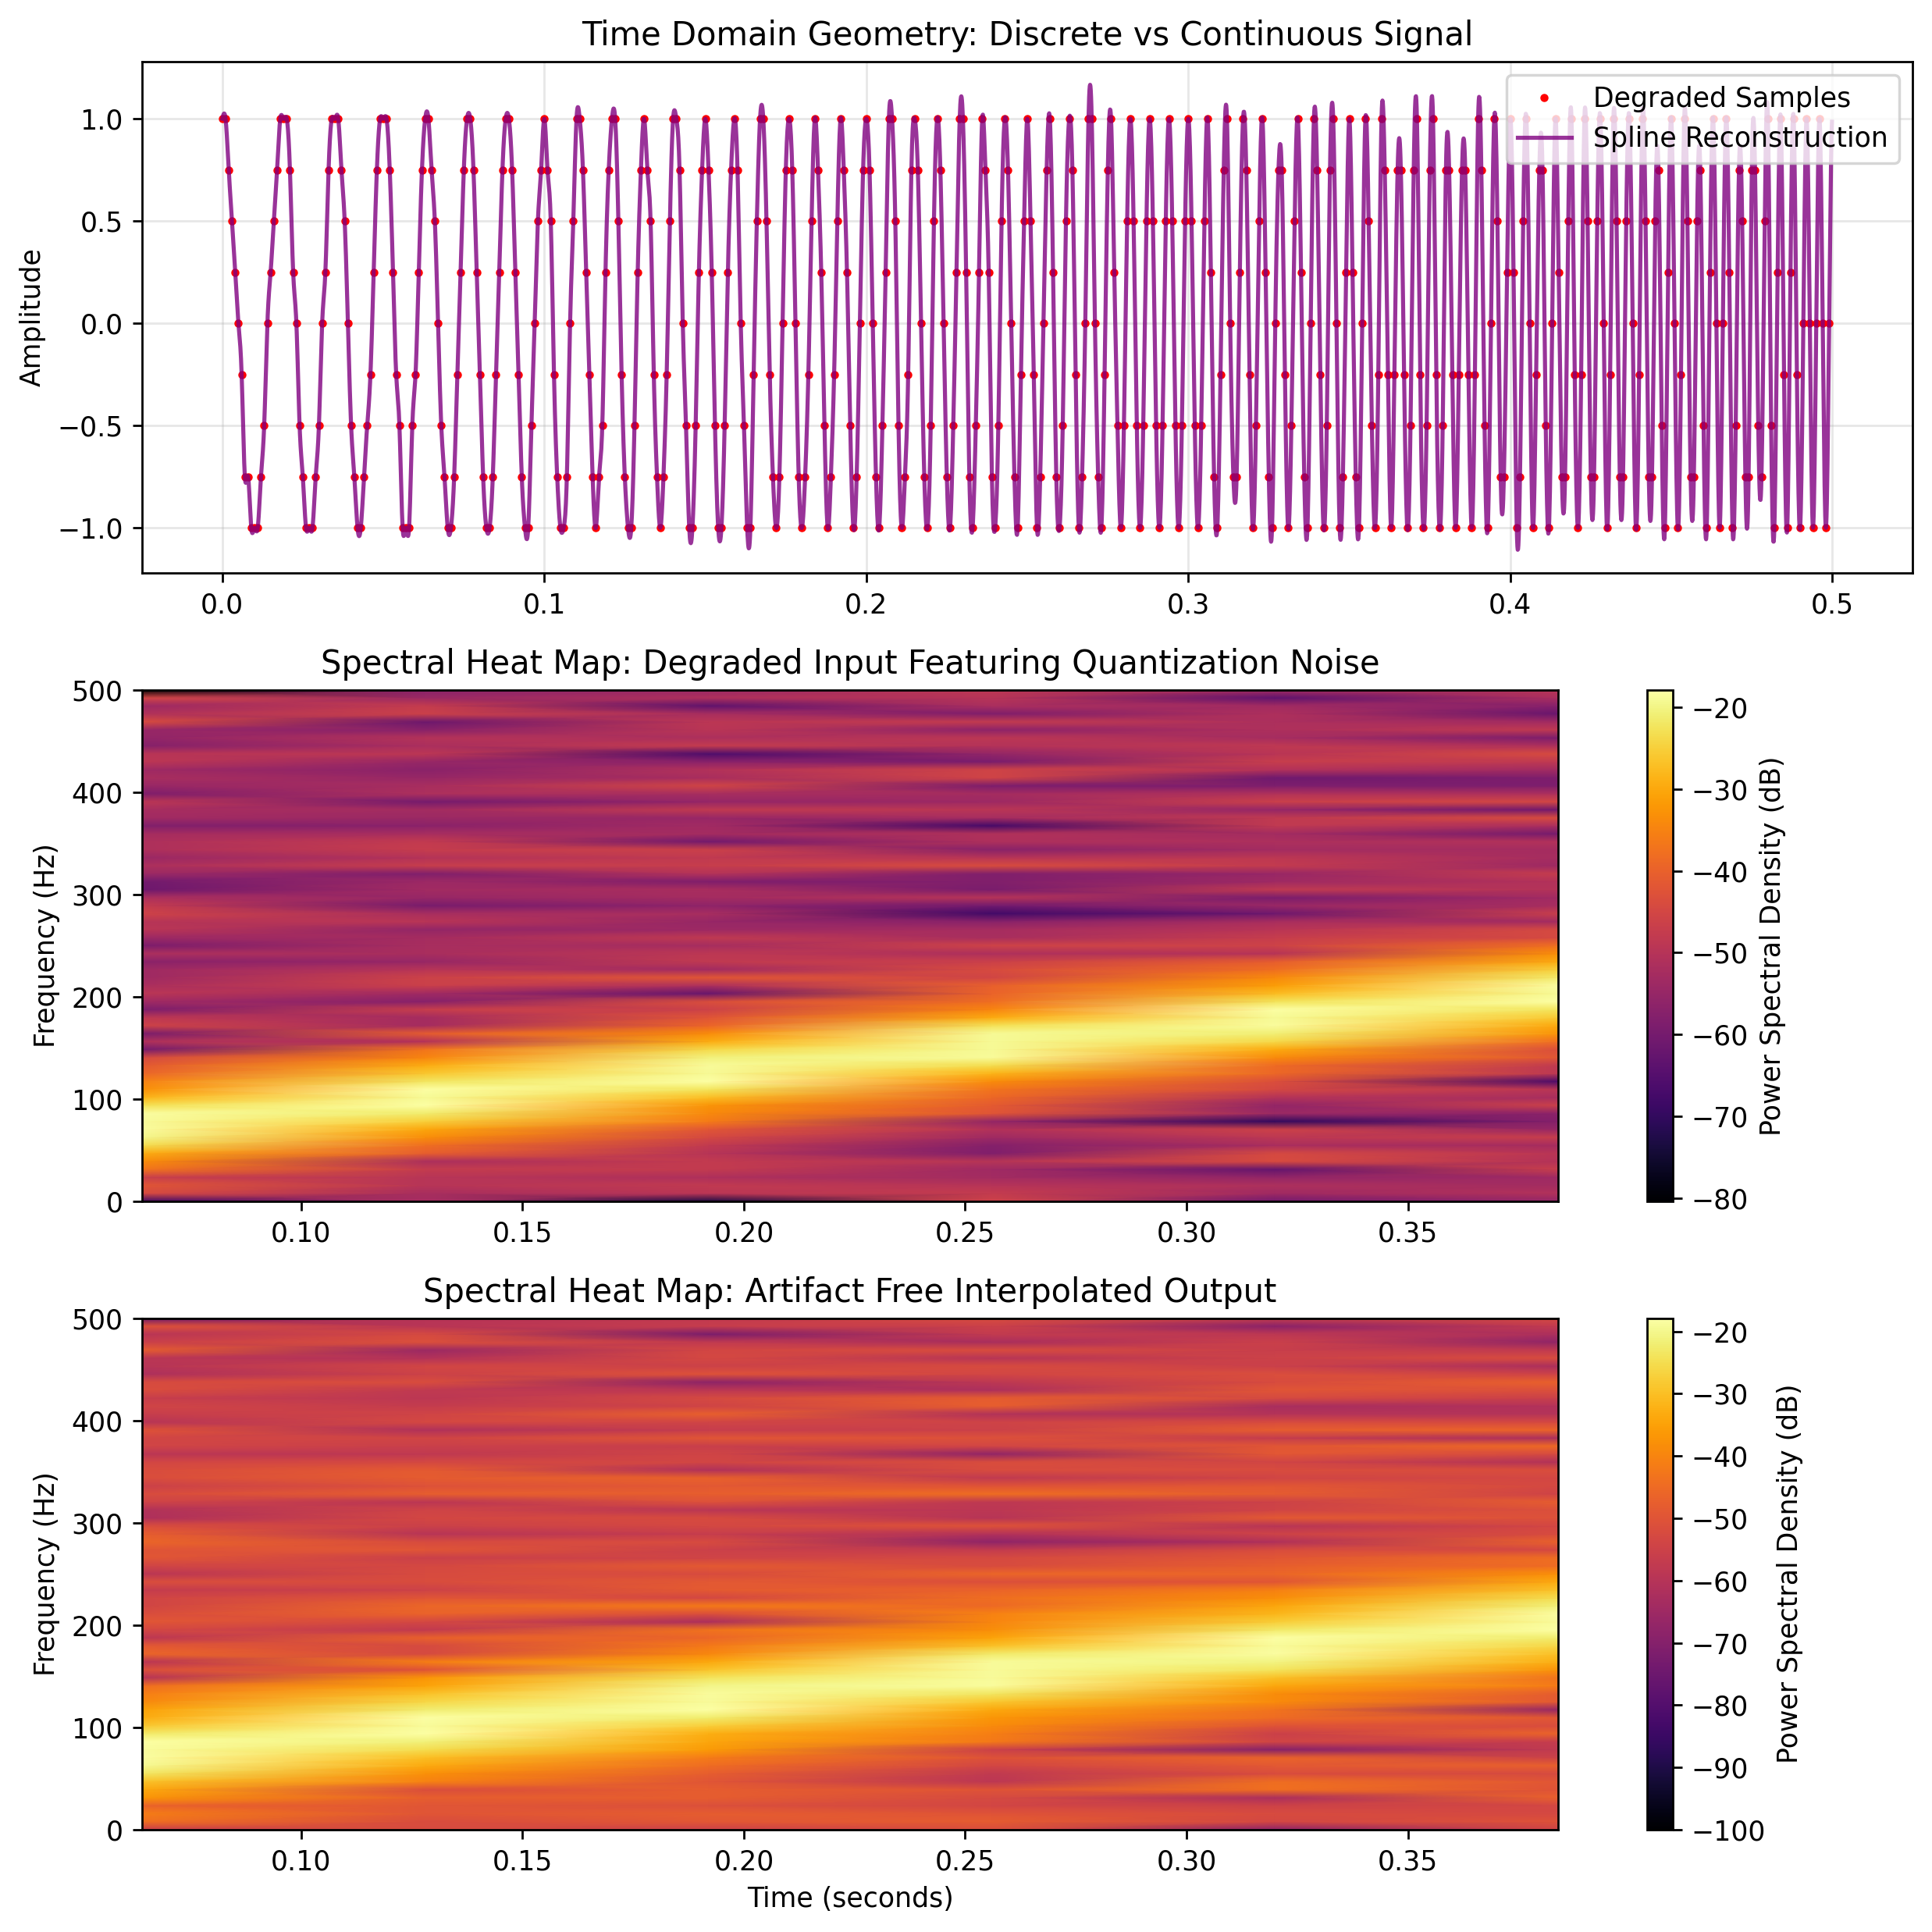

In [5]:
"""
Spectral Interpolation and Heat Map Simulator

Purpose: This computational script evaluates advanced piecewise polynomial
reconstruction methodologies by generating continuous spectrographic heat maps.
The simulation contrasts the spectral density of a degraded, low resolution
digital sweep against a meticulously reconstructed cubic spline output,
highlighting the elimination of high frequency quantization artifacts.
"""

# Control Knobs for Parameter Adjustment
INITIAL_SAMPLE_RATE = 1000       # Starting sampling frequency (Hz)
OVERSAMPLING_MULTIPLIER = 10     # Factor for spline reconstruction (dimensionless)
STARTING_FREQUENCY = 50          # Initial frequency of the acoustic sweep (Hz)
ENDING_FREQUENCY = 250           # Final frequency of the acoustic sweep (Hz)
BIT_DEPTH_RESOLUTION = 3         # Extreme quantization constraint (bits)
SPECTROGRAM_WINDOW_SIZE = 128    # Localized window size for STFT (samples)

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.signal import chirp, spectrogram

# Configure plotting parameters for Google Colab rendering
plt.rcParams['figure.dpi'] = 250
plt.rcParams['font.sans-serif'] = ['Tahoma', 'DejaVu Sans']
plt.rcParams['font.weight'] = 'normal'

def execute_spectral_analysis():
    # Establish the discrete temporal domain
    signal_duration = 0.5
    discrete_sample_count = int(INITIAL_SAMPLE_RATE * signal_duration)
    time_discrete = np.linspace(0, signal_duration, discrete_sample_count, endpoint=False)

    # Generate a fundamental continuous acoustic sweep
    ideal_sweep = chirp(time_discrete, f0=STARTING_FREQUENCY, t1=signal_duration, f1=ENDING_FREQUENCY)

    # Induce severe quantization to create discrete voltage steps
    amplitude_levels = 2 ** BIT_DEPTH_RESOLUTION
    degraded_signal = np.round(ideal_sweep * (amplitude_levels / 2)) / (amplitude_levels / 2)

    # Formulate the highly oversampled continuous time array
    continuous_sample_count = discrete_sample_count * OVERSAMPLING_MULTIPLIER
    time_continuous = np.linspace(0, signal_duration, continuous_sample_count, endpoint=False)

    # Apply the advanced piecewise Cubic Spline mathematical interpolator
    spline_algorithm = CubicSpline(time_discrete, degraded_signal, bc_type='natural')
    reconstructed_signal = spline_algorithm(time_continuous)

    # Calculate the STFT heat maps for both the degraded and reconstructed signals
    freq_deg, time_deg, spec_deg = spectrogram(degraded_signal, fs=INITIAL_SAMPLE_RATE,
                                               nperseg=SPECTROGRAM_WINDOW_SIZE, noverlap=SPECTROGRAM_WINDOW_SIZE//2)

    continuous_sample_rate = INITIAL_SAMPLE_RATE * OVERSAMPLING_MULTIPLIER
    freq_rec, time_rec, spec_rec = spectrogram(reconstructed_signal, fs=continuous_sample_rate,
                                               nperseg=SPECTROGRAM_WINDOW_SIZE * OVERSAMPLING_MULTIPLIER,
                                               noverlap=(SPECTROGRAM_WINDOW_SIZE * OVERSAMPLING_MULTIPLIER)//2)

    # Render the comprehensive visualizations
    fig, axes = plt.subplots(3, 1, figsize=(10, 10))

    # Time Domain Comparison
    axes[0].plot(time_discrete, degraded_signal, 'r.', markersize=4, label='Degraded Samples')
    axes[0].plot(time_continuous, reconstructed_signal, color='purple', linewidth=1.5, alpha=0.8, label='Spline Reconstruction')
    axes[0].set_title('Time Domain Geometry: Discrete vs Continuous Signal')
    axes[0].set_ylabel('Amplitude')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.3)

    # Heat Map 1: Degraded Signal Spectral Density
    mesh1 = axes[1].pcolormesh(time_deg, freq_deg, 10 * np.log10(spec_deg + 1e-10),
                               shading='gouraud', cmap='inferno')
    axes[1].set_title('Spectral Heat Map: Degraded Input Featuring Quantization Noise')
    axes[1].set_ylabel('Frequency (Hz)')
    axes[1].set_ylim(0, INITIAL_SAMPLE_RATE / 2)
    fig.colorbar(mesh1, ax=axes[1], label='Power Spectral Density (dB)')

    # Heat Map 2: Reconstructed Signal Spectral Density
    mesh2 = axes[2].pcolormesh(time_rec, freq_rec, 10 * np.log10(spec_rec + 1e-10),
                               shading='gouraud', cmap='inferno')
    axes[2].set_title('Spectral Heat Map: Artifact Free Interpolated Output')
    axes[2].set_xlabel('Time (seconds)')
    axes[2].set_ylabel('Frequency (Hz)')
    axes[2].set_ylim(0, INITIAL_SAMPLE_RATE / 2)
    fig.colorbar(mesh2, ax=axes[2], label='Power Spectral Density (dB)')

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    execute_spectral_analysis()